# Datathon 2026 — Exploratory Data Analysis

**Datasets available:**
| File | Rows | Mô tả |
|------|------|-------|
| `sales.csv` | 3,833 | Daily Revenue & COGS (2012–2022) — **target** |
| `orders.csv` | 646,945 | Đơn hàng với status, device, source |
| `order_items.csv` | 714,669 | Chi tiết sản phẩm trong đơn |
| `customers.csv` | 121,930 | Thông tin khách hàng |
| `products.csv` | 2,412 | Danh mục sản phẩm, giá, COGS |
| `payments.csv` | 646,945 | Phương thức thanh toán |
| `returns.csv` | 39,939 | Đơn trả hàng |
| `reviews.csv` | 113,551 | Đánh giá sản phẩm |
| `shipments.csv` | 566,067 | Thông tin giao hàng |
| `inventory.csv` | 60,247 | Tồn kho theo tháng |
| `geography.csv` | 39,948 | ZIP → city/region/district |
| `promotions.csv` | 50 | Chương trình khuyến mãi |
| `web_traffic.csv` | 3,652 | Lưu lượng website hàng ngày |

## 0 — Setup

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

BASE = '../data/raw/'

def fmt_vnd(x, pos=None):
    """Format large numbers as billions VND."""
    return f'{x/1e9:.1f}B'

print('Libraries loaded.')

Libraries loaded.


## 1 — Load All Data

In [10]:
sales      = pd.read_csv(BASE+'sales.csv',       parse_dates=['Date'])
orders     = pd.read_csv(BASE+'orders.csv',      parse_dates=['order_date'])
order_items= pd.read_csv(BASE+'order_items.csv', low_memory=False)
customers  = pd.read_csv(BASE+'customers.csv',   parse_dates=['signup_date'])
products   = pd.read_csv(BASE+'products.csv')
payments   = pd.read_csv(BASE+'payments.csv')
returns    = pd.read_csv(BASE+'returns.csv',     parse_dates=['return_date'])
reviews    = pd.read_csv(BASE+'reviews.csv',     parse_dates=['review_date'])
shipments  = pd.read_csv(BASE+'shipments.csv',   parse_dates=['ship_date','delivery_date'])
inventory  = pd.read_csv(BASE+'inventory.csv',   parse_dates=['snapshot_date'])
geography  = pd.read_csv(BASE+'geography.csv')
promotions = pd.read_csv(BASE+'promotions.csv',  parse_dates=['start_date','end_date'])
web        = pd.read_csv(BASE+'web_traffic.csv', parse_dates=['date'])
sample_sub = pd.read_csv(BASE+'sample_submission.csv', parse_dates=['Date'])

print('All data loaded successfully.')

# Quick shape summary
summary = {
    'sales': sales, 'orders': orders, 'order_items': order_items,
    'customers': customers, 'products': products, 'payments': payments,
    'returns': returns, 'reviews': reviews, 'shipments': shipments,
    'inventory': inventory, 'geography': geography,
    'promotions': promotions, 'web_traffic': web,
}
for name, df in summary.items():
    missing = df.isnull().sum().sum()
    print(f'  {name:15s}: {df.shape[0]:>8,} rows x {df.shape[1]:2d} cols | missing cells: {missing:>8,}')

All data loaded successfully.
  sales          :    3,833 rows x  3 cols | missing cells:        0
  orders         :  646,945 rows x  8 cols | missing cells:        0
  order_items    :  714,669 rows x  7 cols | missing cells: 1,152,816
  customers      :  121,930 rows x  7 cols | missing cells:        0
  products       :    2,412 rows x  8 cols | missing cells:        0
  payments       :  646,945 rows x  4 cols | missing cells:        0
  returns        :   39,939 rows x  7 cols | missing cells:        0
  reviews        :  113,551 rows x  7 cols | missing cells:        0
  shipments      :  566,067 rows x  4 cols | missing cells:        0
  inventory      :   60,247 rows x 17 cols | missing cells:        0
  geography      :   39,948 rows x  4 cols | missing cells:        0
  promotions     :       50 rows x 10 cols | missing cells:       40
  web_traffic    :    3,652 rows x  7 cols | missing cells:        0


## 2 — Target Variable: Sales (Revenue & COGS)

In [11]:
sales['year']  = sales['Date'].dt.year
sales['month'] = sales['Date'].dt.month
sales['dow']   = sales['Date'].dt.dayofweek  # 0=Mon
sales['Gross_Profit'] = sales['Revenue'] - sales['COGS']
sales['Margin_pct']   = sales['Gross_Profit'] / sales['Revenue'] * 100

# Annual aggregates
annual = sales.groupby('year').agg(
    Revenue=('Revenue','sum'),
    COGS=('COGS','sum'),
    Gross_Profit=('Gross_Profit','sum')
).reset_index()
annual['Margin_pct'] = annual['Gross_Profit'] / annual['Revenue'] * 100
annual['Rev_YoY']    = annual['Revenue'].pct_change() * 100

print(annual.to_string(index=False, float_format=lambda x: f'{x:,.0f}' if abs(x) > 1 else f'{x:.2f}'))

 year       Revenue          COGS  Gross_Profit  Margin_pct  Rev_YoY
 2012   741,497,748   587,461,924   154,035,824          21      NaN
 2013 1,657,169,417 1,465,980,103   191,189,314          12      123
 2014 1,871,845,883 1,574,607,457   297,238,426          16       13
 2015 1,889,933,827 1,665,441,817   224,492,010          12     0.97
 2016 2,104,640,678 1,780,559,393   324,081,285          15       11
 2017 1,911,164,325 1,694,385,794   216,778,532          11       -9
 2018 1,850,122,456 1,542,175,766   307,946,690          17       -3
 2019 1,136,801,442 1,005,202,884   131,598,558          12      -39
 2020 1,054,512,159   886,085,098   168,427,061          16       -7
 2021 1,043,039,820   941,130,120   101,909,699          10       -1
 2022 1,169,748,832 1,020,420,164   149,328,668          13       12


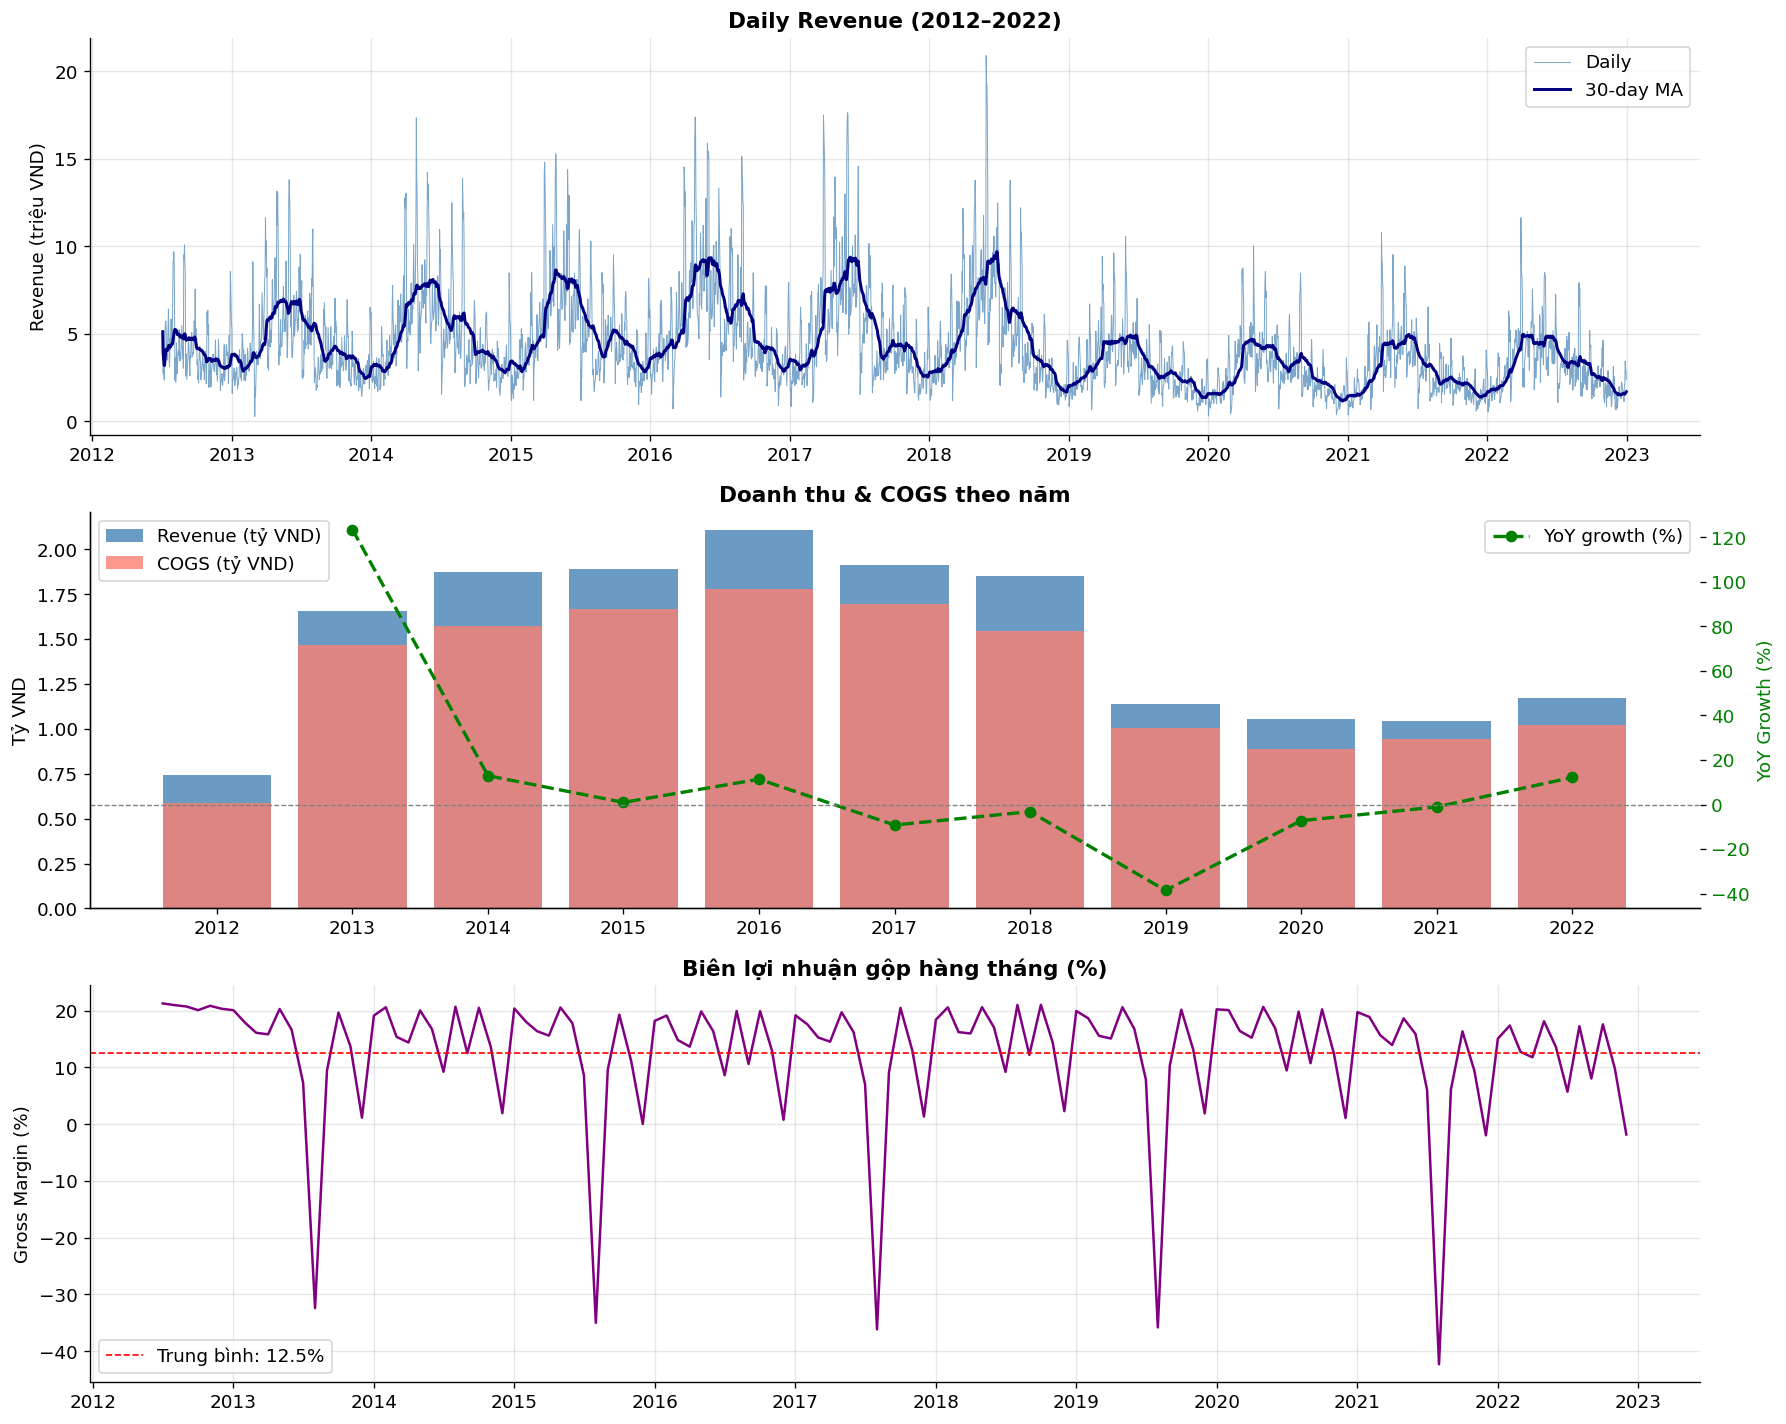

In [12]:
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

# --- Panel 1: Daily Revenue ---
ax = axes[0]
ax.plot(sales['Date'], sales['Revenue']/1e6, lw=0.6, color='steelblue', alpha=0.7, label='Daily')
# 30-day rolling mean
roll = sales.set_index('Date')['Revenue'].rolling('30D').mean()
ax.plot(roll.index, roll/1e6, lw=1.8, color='navy', label='30-day MA')
ax.set_title('Daily Revenue (2012–2022)', fontsize=13, fontweight='bold')
ax.set_ylabel('Revenue (triệu VND)')
ax.legend()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# --- Panel 2: Annual Revenue & YoY growth ---
ax2 = axes[1]
bars = ax2.bar(annual['year'], annual['Revenue']/1e9, color='steelblue', alpha=0.8, label='Revenue (tỷ VND)')
ax2.bar(annual['year'], annual['COGS']/1e9, color='salmon', alpha=0.8, label='COGS (tỷ VND)')
ax2.set_ylabel('Tỷ VND')
ax2.set_title('Doanh thu & COGS theo năm', fontsize=13, fontweight='bold')
ax2.legend(loc='upper left')
ax3 = ax2.twinx()
ax3.plot(annual['year'][1:], annual['Rev_YoY'][1:], 'go--', lw=2, ms=6, label='YoY growth (%)')
ax3.axhline(0, color='gray', lw=0.8, ls='--')
ax3.set_ylabel('YoY Growth (%)', color='green')
ax3.tick_params(axis='y', labelcolor='green')
ax3.legend(loc='upper right')
ax2.set_xticks(annual['year'])
ax2.grid(False)
ax3.grid(False)

# --- Panel 3: Gross Margin % ---
monthly_margin = sales.groupby(['year','month'])['Margin_pct'].mean().reset_index()
monthly_margin['date'] = pd.to_datetime(monthly_margin[['year','month']].assign(day=1))
axes[2].plot(monthly_margin['date'], monthly_margin['Margin_pct'], lw=1.5, color='purple')
axes[2].axhline(sales['Margin_pct'].mean(), color='red', lw=1, ls='--', label=f'Trung bình: {sales["Margin_pct"].mean():.1f}%')
axes[2].set_title('Biên lợi nhuận gộp hàng tháng (%)', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Gross Margin (%)')
axes[2].legend()
axes[2].xaxis.set_major_locator(mdates.YearLocator())
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('eda_01_sales_overview.png', bbox_inches='tight')
plt.show()

## 3 — Phân tích tính mùa vụ (Seasonality)

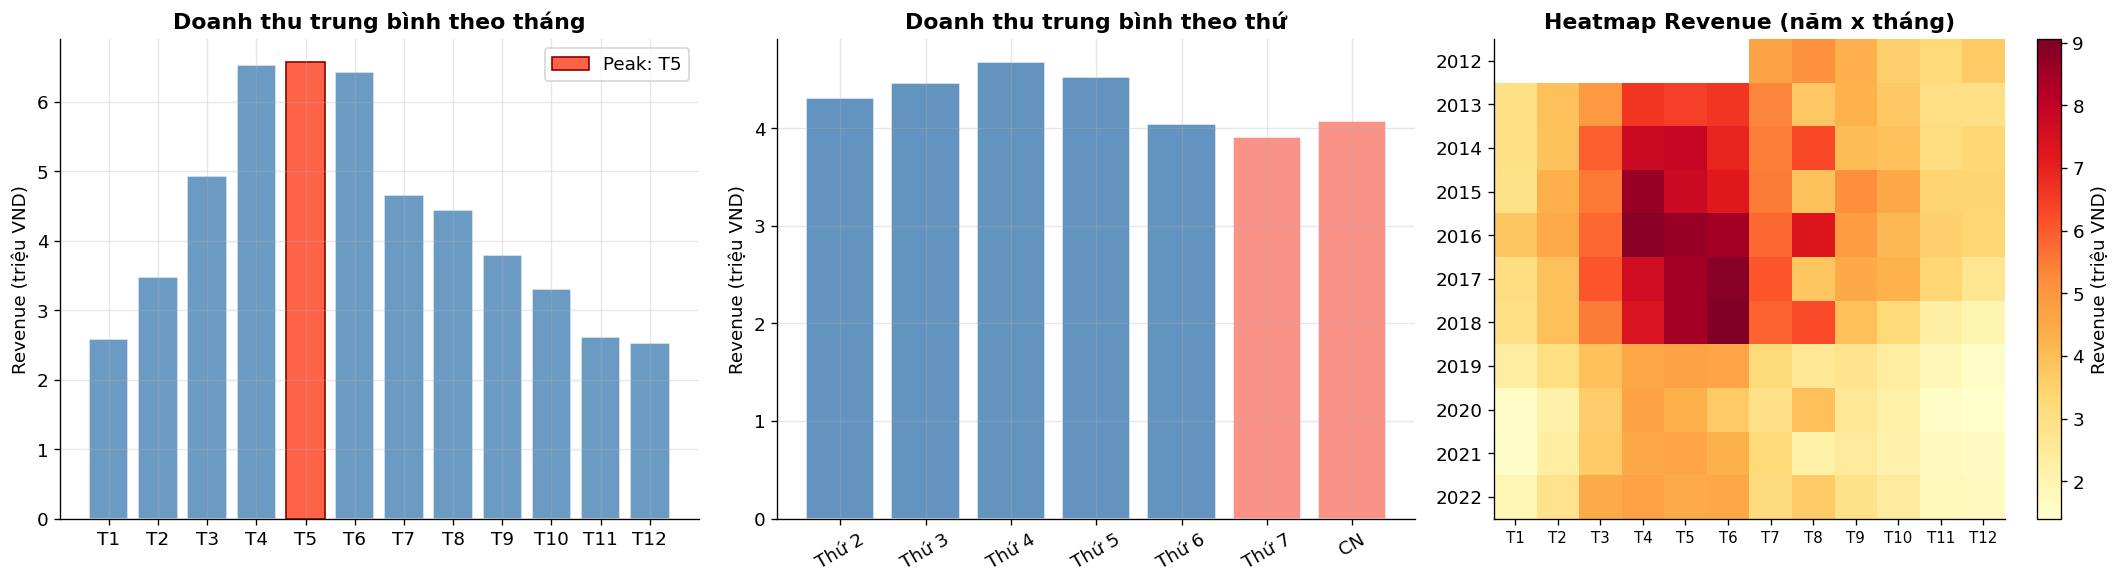

Tháng có doanh thu cao nhất: 5 (6.6M avg)
Ngày có doanh thu cao nhất: Thứ 4 (4.7M avg)
Ngày có doanh thu thấp nhất: Thứ 7 (3.9M avg)


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Monthly seasonality ---
monthly_avg = sales.groupby('month')['Revenue'].mean()
month_names = ['T1','T2','T3','T4','T5','T6','T7','T8','T9','T10','T11','T12']
axes[0].bar(range(1,13), monthly_avg/1e6, color='steelblue', alpha=0.8, edgecolor='white')
axes[0].set_xticks(range(1,13))
axes[0].set_xticklabels(month_names)
axes[0].set_title('Doanh thu trung bình theo tháng', fontweight='bold')
axes[0].set_ylabel('Revenue (triệu VND)')
# highlight peak
peak_m = monthly_avg.idxmax()
axes[0].bar(peak_m, monthly_avg[peak_m]/1e6, color='tomato', alpha=1, edgecolor='darkred', label=f'Peak: T{peak_m}')
axes[0].legend()

# --- Day of week ---
dow_avg = sales.groupby('dow')['Revenue'].mean()
dow_names = ['Thứ 2','Thứ 3','Thứ 4','Thứ 5','Thứ 6','Thứ 7','CN']
colors = ['salmon' if d >= 5 else 'steelblue' for d in range(7)]
axes[1].bar(range(7), dow_avg/1e6, color=colors, alpha=0.85, edgecolor='white')
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(dow_names, rotation=30)
axes[1].set_title('Doanh thu trung bình theo thứ', fontweight='bold')
axes[1].set_ylabel('Revenue (triệu VND)')

# --- Monthly heatmap (year x month) ---
pivot = sales.groupby(['year','month'])['Revenue'].mean().unstack()
im = axes[2].imshow(pivot.values/1e6, aspect='auto', cmap='YlOrRd')
axes[2].set_xticks(range(12))
axes[2].set_xticklabels(month_names, fontsize=9)
axes[2].set_yticks(range(len(pivot.index)))
axes[2].set_yticklabels(pivot.index)
axes[2].set_title('Heatmap Revenue (năm x tháng)', fontweight='bold')
plt.colorbar(im, ax=axes[2], label='Revenue (triệu VND)')
axes[2].grid(False)

plt.tight_layout()
plt.savefig('eda_02_seasonality.png', bbox_inches='tight')
plt.show()

print('Tháng có doanh thu cao nhất:', peak_m, f'({monthly_avg[peak_m]/1e6:.1f}M avg)')
print('Ngày có doanh thu cao nhất:', dow_names[dow_avg.idxmax()], f'({dow_avg.max()/1e6:.1f}M avg)')
print('Ngày có doanh thu thấp nhất:', dow_names[dow_avg.idxmin()], f'({dow_avg.min()/1e6:.1f}M avg)')

## 4 — Phân tích Đơn hàng (Orders)

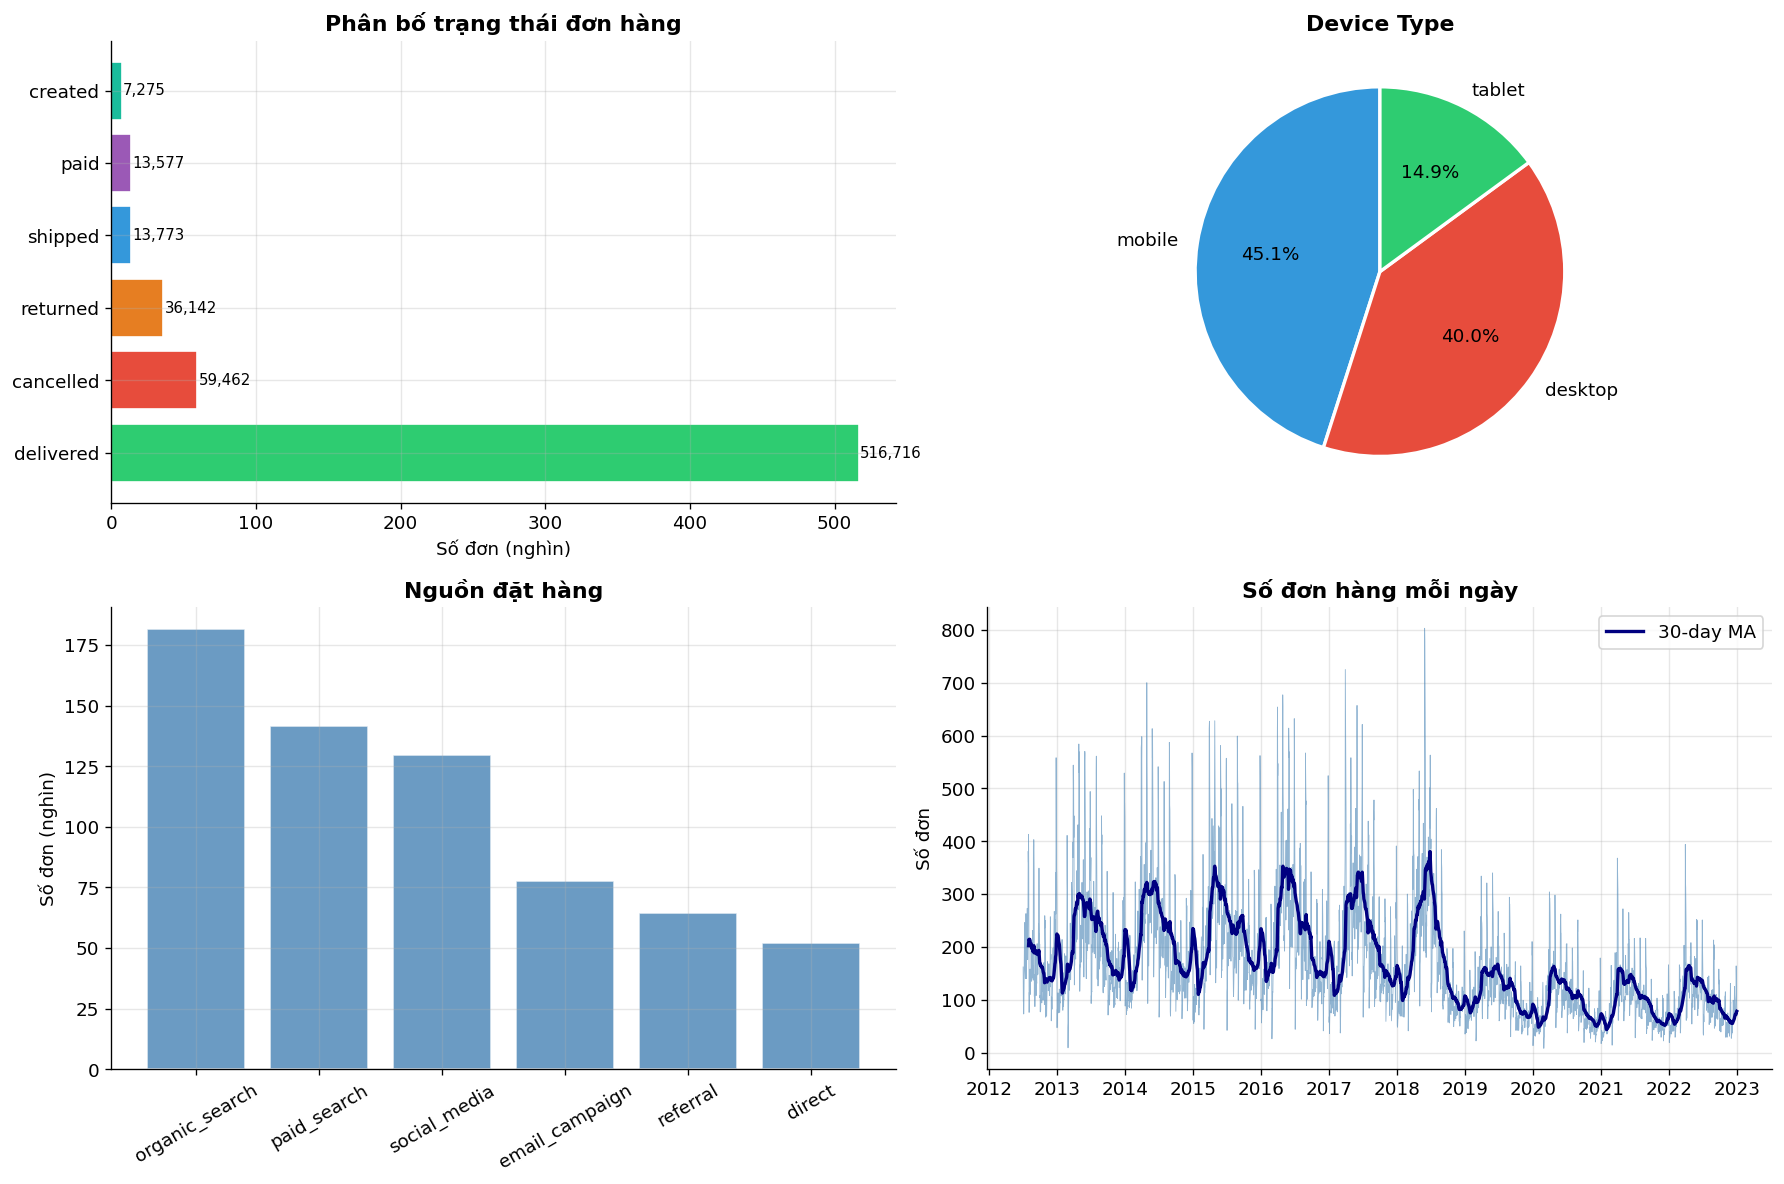

Tỷ lệ hủy đơn: 9.2%
Tỷ lệ trả hàng: 5.6%


In [14]:
orders['year']  = orders['order_date'].dt.year
orders['month'] = orders['order_date'].dt.month

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# --- Order status ---
status_counts = orders['order_status'].value_counts()
colors_status = ['#2ecc71','#e74c3c','#e67e22','#3498db','#9b59b6','#1abc9c']
axes[0,0].barh(status_counts.index, status_counts.values/1000, color=colors_status[:len(status_counts)], edgecolor='white')
axes[0,0].set_xlabel('Số đơn (nghìn)')
axes[0,0].set_title('Phân bố trạng thái đơn hàng', fontweight='bold')
for i, v in enumerate(status_counts.values):
    axes[0,0].text(v/1000 + 1, i, f'{v:,}', va='center', fontsize=9)

# --- Device type ---
device_counts = orders['device_type'].value_counts()
axes[0,1].pie(device_counts.values, labels=device_counts.index, autopct='%1.1f%%',
              colors=['#3498db','#e74c3c','#2ecc71'], startangle=90,
              wedgeprops={'edgecolor':'white','linewidth':2})
axes[0,1].set_title('Device Type', fontweight='bold')

# --- Order source ---
source_counts = orders['order_source'].value_counts()
axes[1,0].bar(source_counts.index, source_counts.values/1000, color='steelblue', alpha=0.8, edgecolor='white')
axes[1,0].set_ylabel('Số đơn (nghìn)')
axes[1,0].set_title('Nguồn đặt hàng', fontweight='bold')
axes[1,0].tick_params(axis='x', rotation=30)

# --- Daily orders over time ---
daily_orders = orders.groupby('order_date').size()
axes[1,1].plot(daily_orders.index, daily_orders.values, lw=0.5, color='steelblue', alpha=0.6)
roll_orders = daily_orders.rolling(30).mean()
axes[1,1].plot(roll_orders.index, roll_orders.values, lw=2, color='navy', label='30-day MA')
axes[1,1].set_title('Số đơn hàng mỗi ngày', fontweight='bold')
axes[1,1].set_ylabel('Số đơn')
axes[1,1].legend()
axes[1,1].xaxis.set_major_locator(mdates.YearLocator())
axes[1,1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('eda_03_orders.png', bbox_inches='tight')
plt.show()

cancel_rate = orders[orders['order_status']=='cancelled'].shape[0] / len(orders) * 100
return_rate = orders[orders['order_status']=='returned'].shape[0] / len(orders) * 100
print(f'Tỷ lệ hủy đơn: {cancel_rate:.1f}%')
print(f'Tỷ lệ trả hàng: {return_rate:.1f}%')

## 5 — Phân tích Khách hàng (Customers)

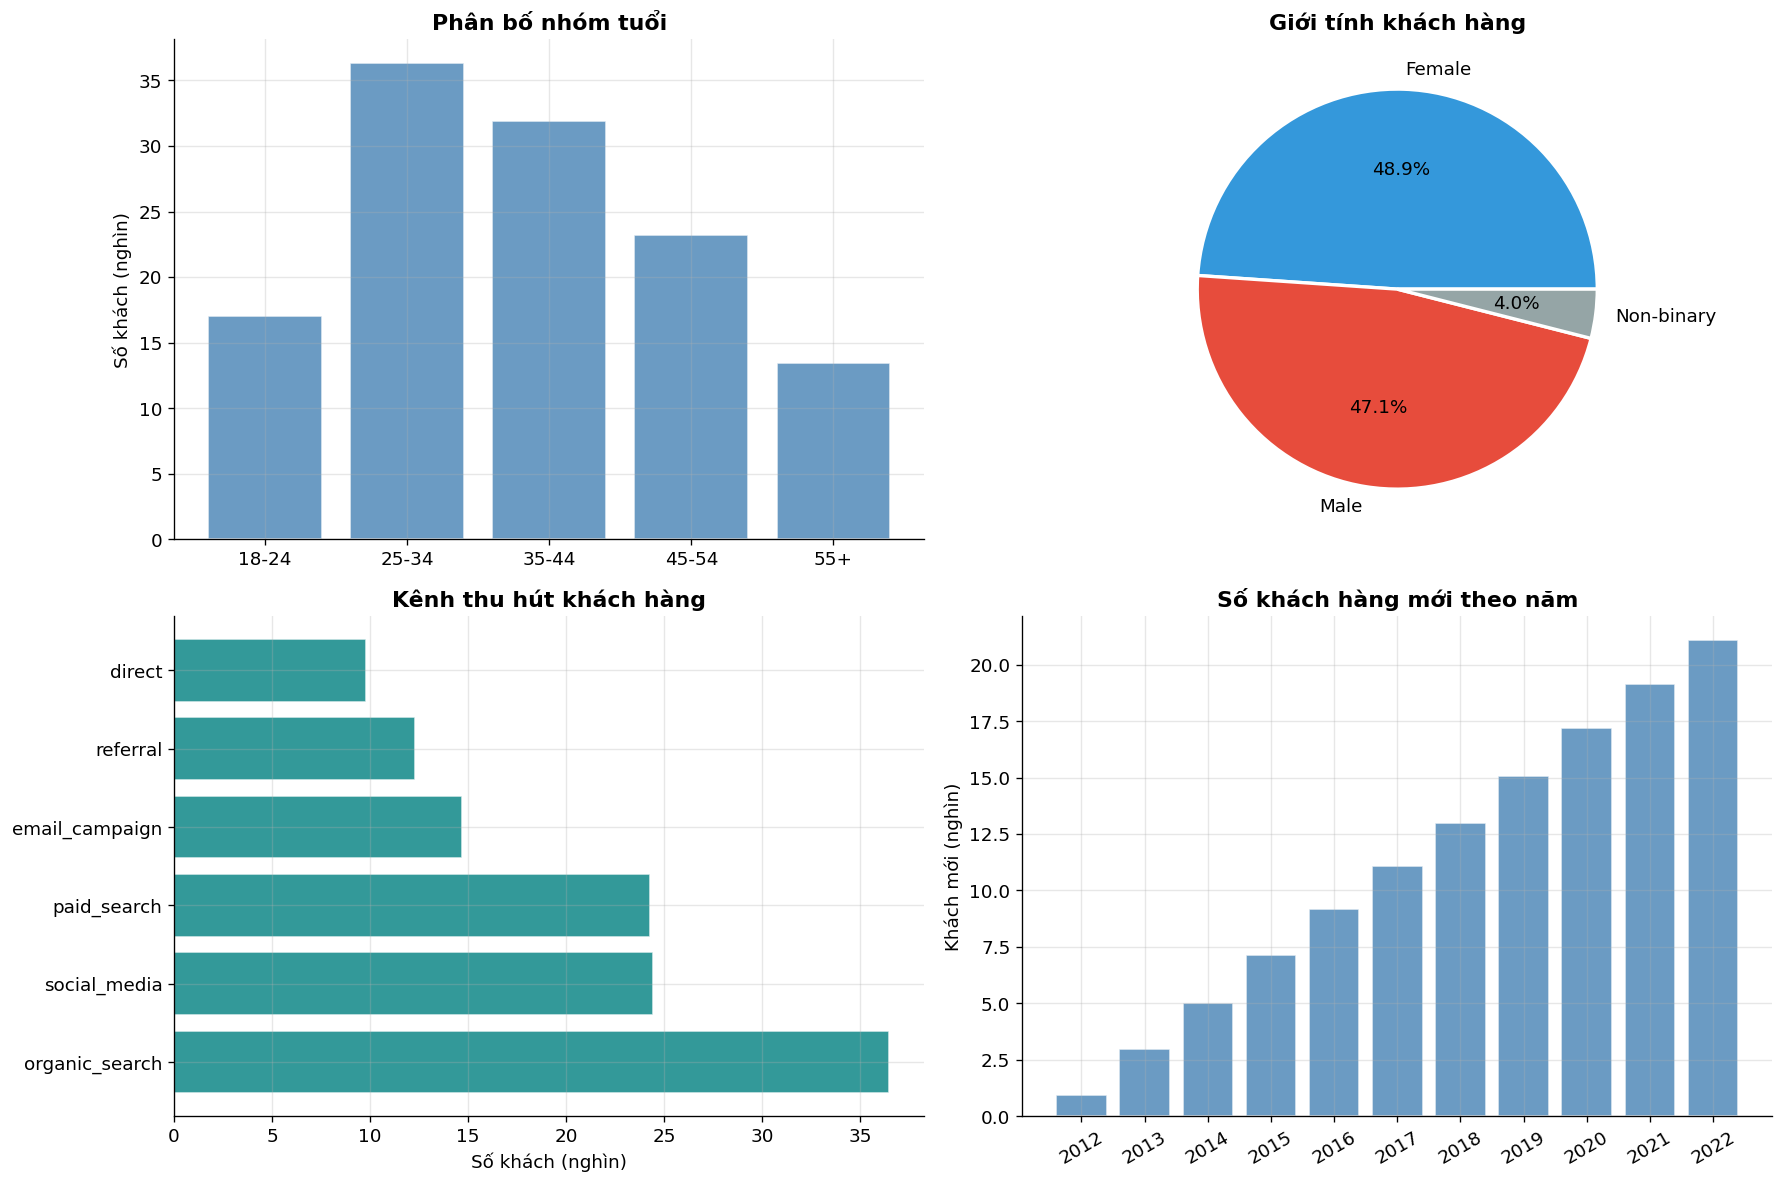

Phân bố theo vùng:
region
East       58178
Central    44286
West       19466
Name: count, dtype: int64


In [15]:
customers['signup_year'] = customers['signup_date'].dt.year

# Merge with geography
cust_geo = customers.merge(geography[['zip','region']].drop_duplicates('zip'), on='zip', how='left')

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# --- Age group distribution ---
age_dist = customers['age_group'].value_counts().sort_index()
axes[0,0].bar(age_dist.index, age_dist.values/1000, color='steelblue', alpha=0.8, edgecolor='white')
axes[0,0].set_ylabel('Số khách (nghìn)')
axes[0,0].set_title('Phân bố nhóm tuổi', fontweight='bold')

# --- Gender ---
gender_dist = customers['gender'].value_counts()
axes[0,1].pie(gender_dist.values, labels=gender_dist.index, autopct='%1.1f%%',
              colors=['#3498db','#e74c3c','#95a5a6'],
              wedgeprops={'edgecolor':'white','linewidth':2})
axes[0,1].set_title('Giới tính khách hàng', fontweight='bold')

# --- Acquisition channel ---
acq_dist = customers['acquisition_channel'].value_counts()
axes[1,0].barh(acq_dist.index, acq_dist.values/1000, color='teal', alpha=0.8, edgecolor='white')
axes[1,0].set_xlabel('Số khách (nghìn)')
axes[1,0].set_title('Kênh thu hút khách hàng', fontweight='bold')

# --- New customers per year ---
new_cust = customers.groupby('signup_year').size()
axes[1,1].bar(new_cust.index, new_cust.values/1000, color='steelblue', alpha=0.8, edgecolor='white')
axes[1,1].set_ylabel('Khách mới (nghìn)')
axes[1,1].set_title('Số khách hàng mới theo năm', fontweight='bold')
axes[1,1].set_xticks(new_cust.index)
axes[1,1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('eda_04_customers.png', bbox_inches='tight')
plt.show()

# Region distribution
print('Phân bố theo vùng:')
print(cust_geo['region'].value_counts().head(10))

## 6 — Phân tích Sản phẩm & Danh mục

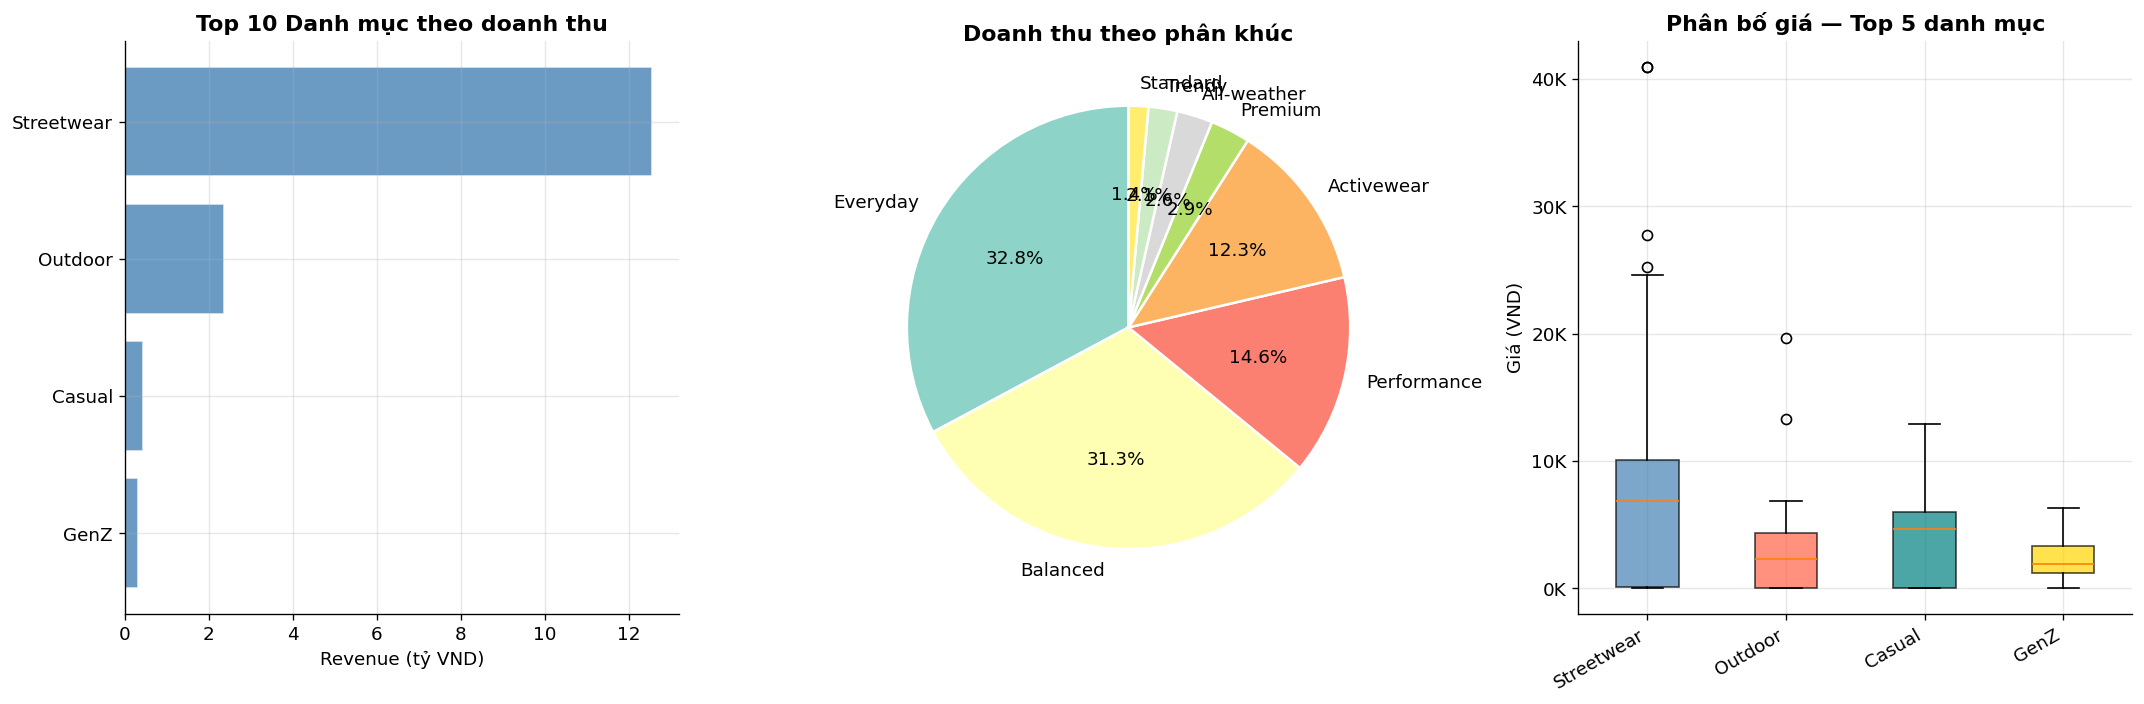

Số danh mục: 4
Số phân khúc: 8
Giá sản phẩm: 9 → 40,950 VND


In [16]:
# Merge order items with products
oi_prod = order_items.merge(products[['product_id','category','segment','price','cogs']], on='product_id', how='left')
oi_prod['revenue_item'] = oi_prod['unit_price'] * oi_prod['quantity'] - oi_prod['discount_amount']
oi_prod['cogs_item']    = oi_prod['cogs'] * oi_prod['quantity']

# Revenue by category
cat_rev = oi_prod.groupby('category')['revenue_item'].sum().sort_values(ascending=False)
seg_rev = oi_prod.groupby('segment')['revenue_item'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- Revenue by category ---
axes[0].barh(cat_rev.index[:10], cat_rev.values[:10]/1e9, color='steelblue', alpha=0.8, edgecolor='white')
axes[0].set_xlabel('Revenue (tỷ VND)')
axes[0].set_title('Top 10 Danh mục theo doanh thu', fontweight='bold')
axes[0].invert_yaxis()

# --- Revenue by segment ---
colors_seg = plt.cm.Set3(np.linspace(0, 1, len(seg_rev)))
axes[1].pie(seg_rev.values[:8], labels=seg_rev.index[:8], autopct='%1.1f%%',
            colors=colors_seg, startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[1].set_title('Doanh thu theo phân khúc', fontweight='bold')

# --- Price distribution by category ---
top5_cats = cat_rev.index[:5]
data_box = [products[products['category']==c]['price'].values for c in top5_cats]
bp = axes[2].boxplot(data_box, patch_artist=True, vert=True)
colors_box = ['steelblue','tomato','teal','gold','purple']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[2].set_xticklabels([c[:12] for c in top5_cats], rotation=30, ha='right')
axes[2].set_ylabel('Giá (VND)')
axes[2].set_title('Phân bố giá — Top 5 danh mục', fontweight='bold')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,p: f'{x/1e3:.0f}K'))

plt.tight_layout()
plt.savefig('eda_05_products.png', bbox_inches='tight')
plt.show()

print('Số danh mục:', products['category'].nunique())
print('Số phân khúc:', products['segment'].nunique())
print(f'Giá sản phẩm: {products["price"].min():,.0f} → {products["price"].max():,.0f} VND')

## 7 — Phân tích Thanh toán & Khuyến mãi

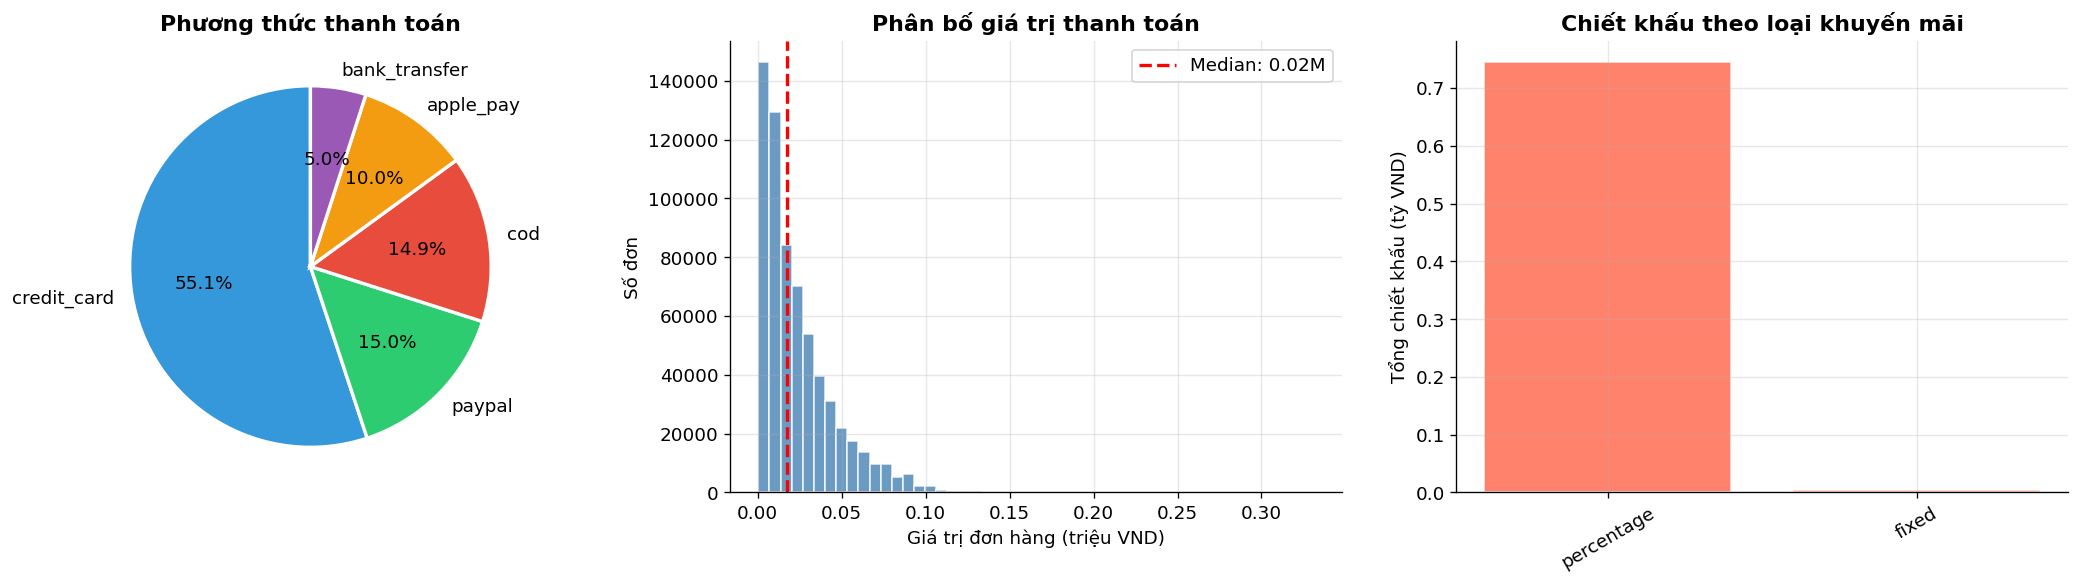

Giá trị đơn hàng trung bình: 0.02M VND
Giá trị đơn hàng median: 0.02M VND
Tỷ lệ đơn có khuyến mãi: 38.7%


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Payment method distribution ---
pay_dist = payments['payment_method'].value_counts()
axes[0].pie(pay_dist.values, labels=pay_dist.index, autopct='%1.1f%%',
            colors=['#3498db','#2ecc71','#e74c3c','#f39c12','#9b59b6'],
            wedgeprops={'edgecolor':'white','linewidth':2}, startangle=90)
axes[0].set_title('Phương thức thanh toán', fontweight='bold')

# --- Payment value distribution ---
axes[1].hist(payments['payment_value']/1e6, bins=50, color='steelblue', alpha=0.8, edgecolor='white')
axes[1].set_xlabel('Giá trị đơn hàng (triệu VND)')
axes[1].set_ylabel('Số đơn')
axes[1].set_title('Phân bố giá trị thanh toán', fontweight='bold')
axes[1].axvline(payments['payment_value'].median()/1e6, color='red', lw=2, ls='--',
                label=f'Median: {payments["payment_value"].median()/1e6:.2f}M')
axes[1].legend()

# --- Promotions discount by type ---
# Discount usage per promo type
oi_promo = order_items.merge(promotions[['promo_id','promo_type','discount_value']], on='promo_id', how='inner')
promo_impact = oi_promo.groupby('promo_type')['discount_amount'].agg(['sum','count'])
promo_impact.columns = ['total_discount','num_orders']
promo_impact = promo_impact.sort_values('total_discount', ascending=False)
axes[2].bar(promo_impact.index, promo_impact['total_discount']/1e9, color='tomato', alpha=0.8, edgecolor='white')
axes[2].set_ylabel('Tổng chiết khấu (tỷ VND)')
axes[2].set_title('Chiết khấu theo loại khuyến mãi', fontweight='bold')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('eda_06_payments_promos.png', bbox_inches='tight')
plt.show()

print(f'Giá trị đơn hàng trung bình: {payments["payment_value"].mean()/1e6:.2f}M VND')
print(f'Giá trị đơn hàng median: {payments["payment_value"].median()/1e6:.2f}M VND')
pct_promo = (order_items['promo_id'].notna().sum() / len(order_items)) * 100
print(f'Tỷ lệ đơn có khuyến mãi: {pct_promo:.1f}%')

## 8 — Trả hàng & Đánh giá

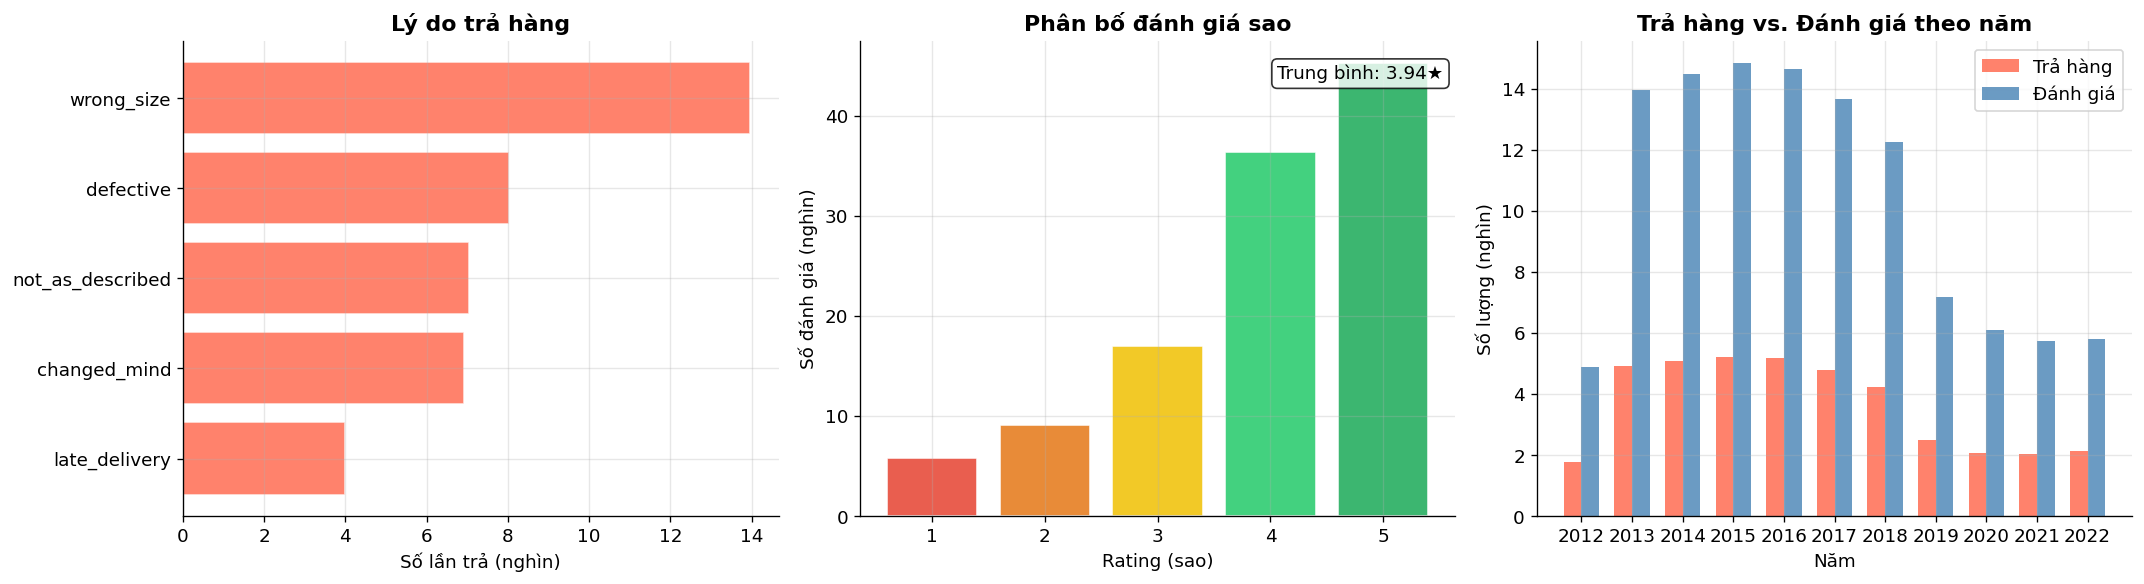

Tỷ lệ trả hàng thực tế: 7.2%
Rating trung bình: 3.94 / 5.0


In [18]:
returns['year'] = returns['return_date'].dt.year
reviews['year'] = reviews['review_date'].dt.year

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Return reasons ---
ret_reasons = returns['return_reason'].value_counts().head(8)
axes[0].barh(ret_reasons.index, ret_reasons.values/1000, color='tomato', alpha=0.8, edgecolor='white')
axes[0].set_xlabel('Số lần trả (nghìn)')
axes[0].set_title('Lý do trả hàng', fontweight='bold')
axes[0].invert_yaxis()

# --- Rating distribution ---
rating_dist = reviews['rating'].value_counts().sort_index()
colors_rating = ['#e74c3c','#e67e22','#f1c40f','#2ecc71','#27ae60']
axes[1].bar(rating_dist.index, rating_dist.values/1000, color=colors_rating, alpha=0.9, edgecolor='white')
axes[1].set_xlabel('Rating (sao)')
axes[1].set_ylabel('Số đánh giá (nghìn)')
axes[1].set_title('Phân bố đánh giá sao', fontweight='bold')
axes[1].set_xticks([1,2,3,4,5])
avg_rating = reviews['rating'].mean()
axes[1].text(0.98, 0.95, f'Trung bình: {avg_rating:.2f}★',
             transform=axes[1].transAxes, ha='right', va='top', fontsize=11,
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# --- Returns & Reviews per year ---
ret_year = returns.groupby('year').size()
rev_year = reviews.groupby('year').size()
x = np.array(sorted(set(ret_year.index) & set(rev_year.index)))
w = 0.35
axes[2].bar(x - w/2, ret_year.reindex(x)/1000, w, label='Trả hàng', color='tomato', alpha=0.8)
axes[2].bar(x + w/2, rev_year.reindex(x)/1000, w, label='Đánh giá', color='steelblue', alpha=0.8)
axes[2].set_xlabel('Năm')
axes[2].set_ylabel('Số lượng (nghìn)')
axes[2].set_title('Trả hàng vs. Đánh giá theo năm', fontweight='bold')
axes[2].legend()
axes[2].set_xticks(x)

plt.tight_layout()
plt.savefig('eda_07_returns_reviews.png', bbox_inches='tight')
plt.show()

ret_rate = len(returns) / orders[orders['order_status'].isin(['delivered','returned'])].shape[0] * 100
print(f'Tỷ lệ trả hàng thực tế: {ret_rate:.1f}%')
print(f'Rating trung bình: {avg_rating:.2f} / 5.0')

## 9 — Web Traffic & Mối quan hệ với Doanh thu

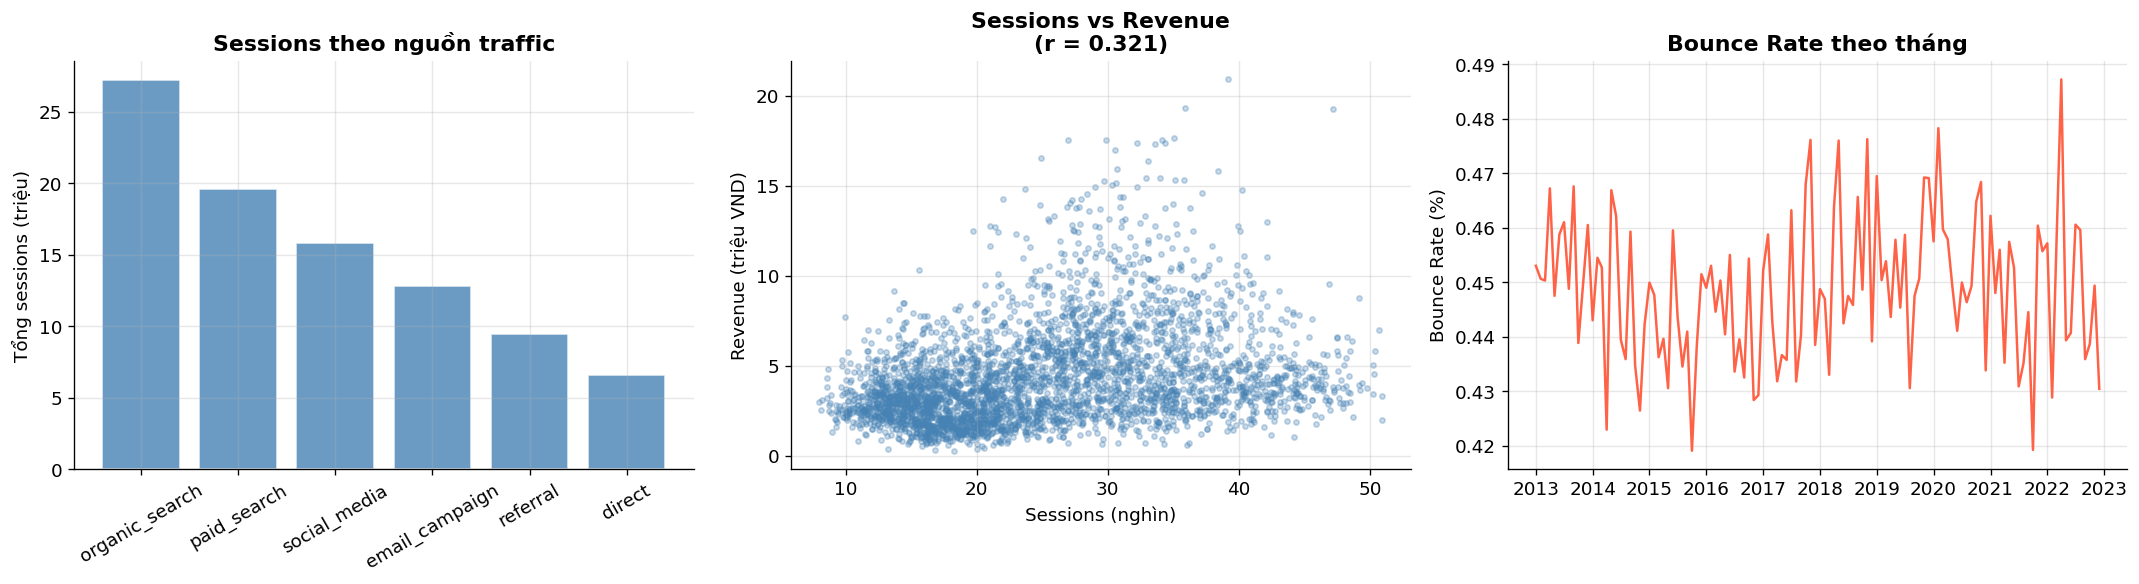

Tương quan sessions ↔ Revenue: 0.321
Avg bounce rate: 0.4%


In [19]:
web['year'] = web['date'].dt.year

# Merge web traffic with daily sales
web_sales = web.groupby('date').agg(
    sessions=('sessions','sum'),
    visitors=('unique_visitors','sum')
).reset_index()
web_sales = web_sales.merge(sales[['Date','Revenue']], left_on='date', right_on='Date', how='inner')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Traffic source ---
src_dist = web.groupby('traffic_source')['sessions'].sum().sort_values(ascending=False)
axes[0].bar(src_dist.index, src_dist.values/1e6, color='steelblue', alpha=0.8, edgecolor='white')
axes[0].set_ylabel('Tổng sessions (triệu)')
axes[0].set_title('Sessions theo nguồn traffic', fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)

# --- Sessions vs Revenue scatter ---
axes[1].scatter(web_sales['sessions']/1000, web_sales['Revenue']/1e6,
                alpha=0.3, s=10, color='steelblue')
corr = web_sales['sessions'].corr(web_sales['Revenue'])
axes[1].set_xlabel('Sessions (nghìn)')
axes[1].set_ylabel('Revenue (triệu VND)')
axes[1].set_title(f'Sessions vs Revenue\n(r = {corr:.3f})', fontweight='bold')

# --- Bounce rate over time ---
bounce_monthly = web.groupby([web['date'].dt.year, web['date'].dt.month])['bounce_rate'].mean()
bounce_monthly.index = pd.MultiIndex.from_tuples(bounce_monthly.index, names=['year','month'])
bounce_monthly = bounce_monthly.reset_index()
bounce_monthly['date'] = pd.to_datetime(bounce_monthly[['year','month']].assign(day=1))
axes[2].plot(bounce_monthly['date'], bounce_monthly['bounce_rate']*100, color='tomato', lw=1.5)
axes[2].set_ylabel('Bounce Rate (%)')
axes[2].set_title('Bounce Rate theo tháng', fontweight='bold')
axes[2].xaxis.set_major_locator(mdates.YearLocator())
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('eda_08_web_traffic.png', bbox_inches='tight')
plt.show()

print(f'Tương quan sessions ↔ Revenue: {corr:.3f}')
print(f'Avg bounce rate: {web["bounce_rate"].mean()*100:.1f}%')

## 10 — Tồn kho (Inventory)

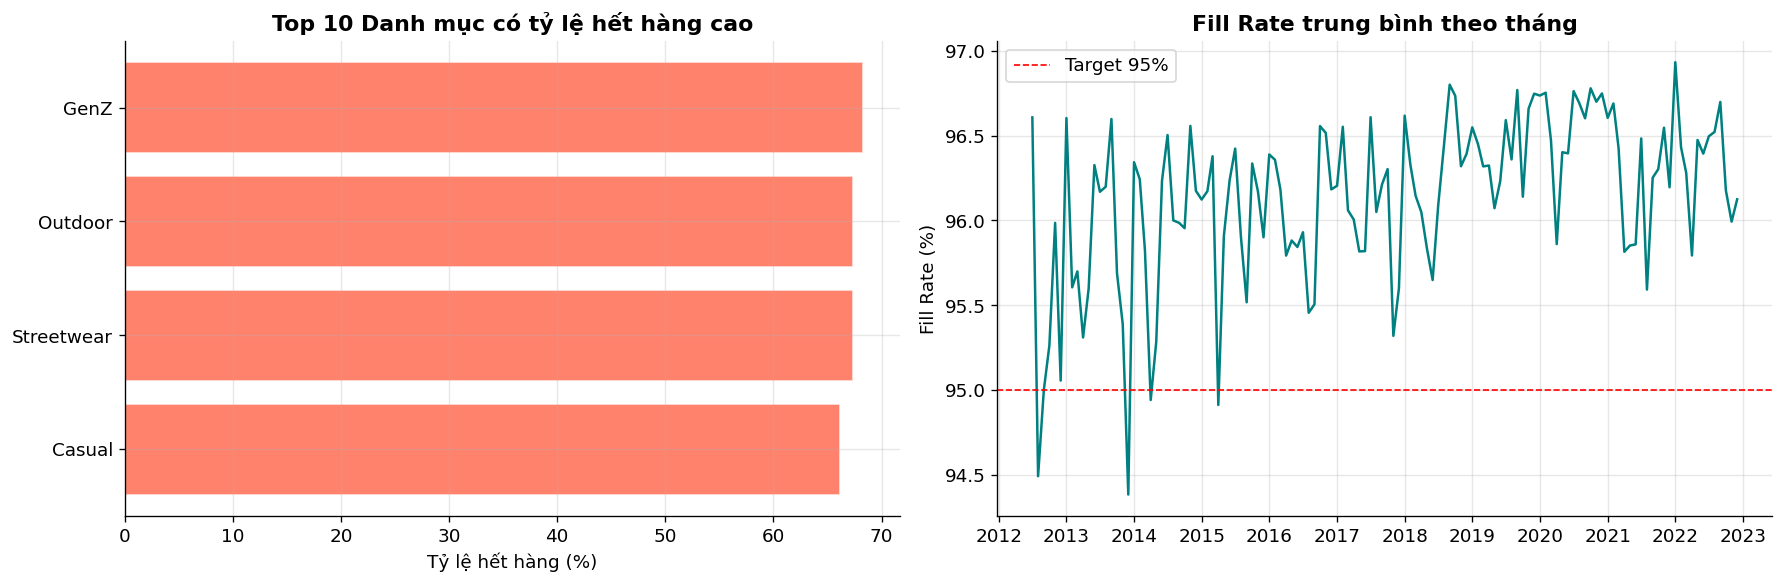

Tỷ lệ hết hàng toàn hệ thống: 67.3%
Fill rate trung bình: 96.1%


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# --- Stockout rate by category ---
stockout_cat = inventory.groupby('category')['stockout_flag'].mean().sort_values(ascending=False).head(10)
axes[0].barh(stockout_cat.index, stockout_cat.values * 100, color='tomato', alpha=0.8, edgecolor='white')
axes[0].set_xlabel('Tỷ lệ hết hàng (%)')
axes[0].set_title('Top 10 Danh mục có tỷ lệ hết hàng cao', fontweight='bold')
axes[0].invert_yaxis()

# --- Fill rate trend ---
fill_monthly = inventory.groupby(['year','month'])['fill_rate'].mean().reset_index()
fill_monthly['date'] = pd.to_datetime(fill_monthly[['year','month']].assign(day=1))
axes[1].plot(fill_monthly['date'], fill_monthly['fill_rate']*100, color='teal', lw=1.5)
axes[1].axhline(95, color='red', lw=1, ls='--', label='Target 95%')
axes[1].set_ylabel('Fill Rate (%)')
axes[1].set_title('Fill Rate trung bình theo tháng', fontweight='bold')
axes[1].legend()
axes[1].xaxis.set_major_locator(mdates.YearLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('eda_09_inventory.png', bbox_inches='tight')
plt.show()

print(f'Tỷ lệ hết hàng toàn hệ thống: {inventory["stockout_flag"].mean()*100:.1f}%')
print(f'Fill rate trung bình: {inventory["fill_rate"].mean()*100:.1f}%')

## 11 — Giao hàng (Delivery Performance)

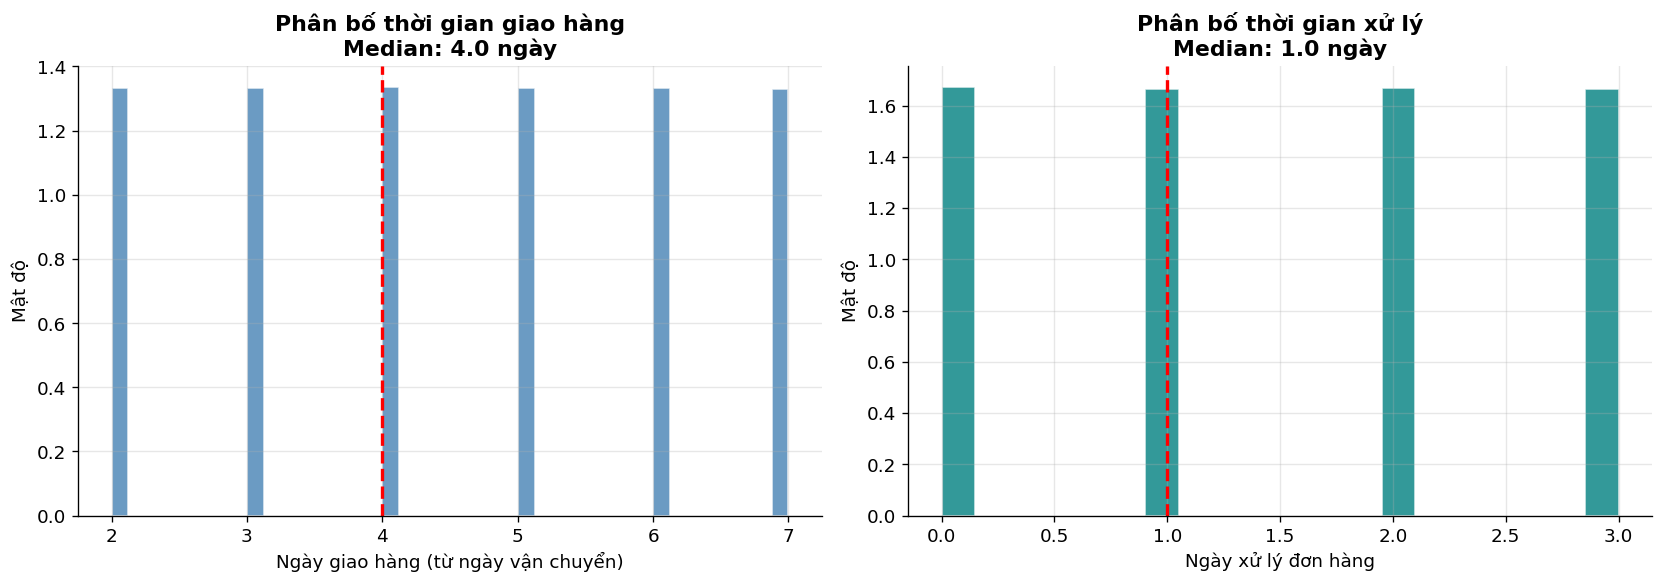

In [21]:
# Calculate delivery time
ship_valid = shipments.dropna(subset=['ship_date','delivery_date'])
ship_valid = ship_valid.merge(orders[['order_id','order_date']], on='order_id', how='left')
ship_valid['processing_days'] = (ship_valid['ship_date']   - ship_valid['order_date']).dt.days
ship_valid['delivery_days']   = (ship_valid['delivery_date'] - ship_valid['ship_date']).dt.days
ship_valid['total_days']      = (ship_valid['delivery_date'] - ship_valid['order_date']).dt.days

# Remove obvious outliers
sv = ship_valid[
    (ship_valid['processing_days'] >= 0) & (ship_valid['processing_days'] <= 30) &
    (ship_valid['delivery_days']   >= 0) & (ship_valid['delivery_days']   <= 60)
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(sv['delivery_days'], bins=40, color='steelblue', alpha=0.8, edgecolor='white', density=True)
axes[0].set_xlabel('Ngày giao hàng (từ ngày vận chuyển)')
axes[0].set_ylabel('Mật độ')
axes[0].set_title(f'Phân bố thời gian giao hàng\nMedian: {sv["delivery_days"].median():.1f} ngày', fontweight='bold')
axes[0].axvline(sv['delivery_days'].median(), color='red', lw=2, ls='--')

axes[1].hist(sv['processing_days'], bins=20, color='teal', alpha=0.8, edgecolor='white', density=True)
axes[1].set_xlabel('Ngày xử lý đơn hàng')
axes[1].set_ylabel('Mật độ')
axes[1].set_title(f'Phân bố thời gian xử lý\nMedian: {sv["processing_days"].median():.1f} ngày', fontweight='bold')
axes[1].axvline(sv['processing_days'].median(), color='red', lw=2, ls='--')

plt.tight_layout()
plt.savefig('eda_10_delivery.png', bbox_inches='tight')
plt.show()

## 12 — Tương quan với Revenue: Các nhân tố chính

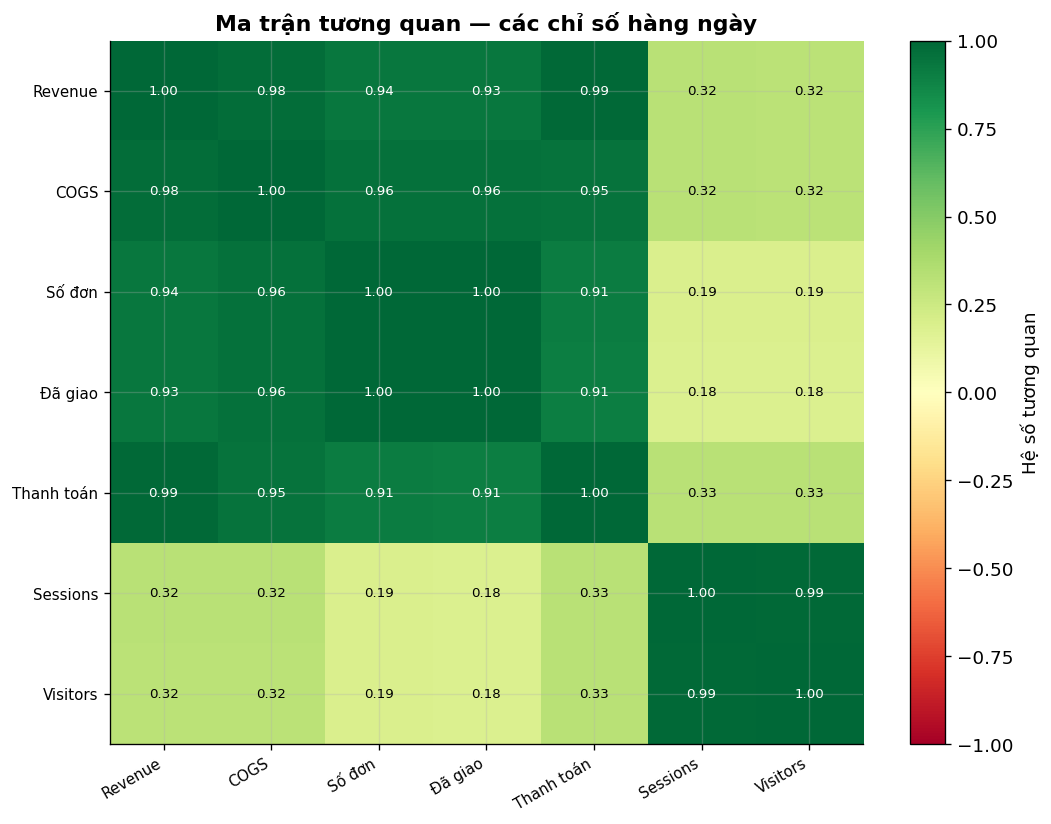

Tương quan với Revenue:
  daily_payment_value           : 0.9921
  COGS                          : 0.9760
  num_orders                    : 0.9359
  num_delivered                 : 0.9331
  sessions                      : 0.3211
  unique_visitors               : 0.3188


In [22]:
# Build a daily feature table
daily_orders_cnt = orders.groupby('order_date').agg(
    num_orders=('order_id','count'),
    num_delivered=('order_status', lambda x: (x=='delivered').sum()),
    num_cancelled=('order_status', lambda x: (x=='cancelled').sum()),
).reset_index()

daily_pay = payments.merge(orders[['order_id','order_date']], on='order_id', how='left')
daily_pay = daily_pay.groupby('order_date')['payment_value'].sum().reset_index()
daily_pay.columns = ['order_date','daily_payment_value']

daily_web = web.groupby('date').agg(
    sessions=('sessions','sum'),
    unique_visitors=('unique_visitors','sum')
).reset_index().rename(columns={'date':'order_date'})

# Combine
daily_features = sales.rename(columns={'Date':'order_date'})
daily_features = daily_features.merge(daily_orders_cnt, on='order_date', how='left')
daily_features = daily_features.merge(daily_pay,        on='order_date', how='left')
daily_features = daily_features.merge(daily_web,        on='order_date', how='left')

numeric_cols = ['Revenue', 'COGS', 'num_orders', 'num_delivered', 'daily_payment_value', 'sessions', 'unique_visitors']
corr_matrix = daily_features[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr_matrix.values, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, label='Hệ số tương quan')

labels = ['Revenue', 'COGS', 'Số đơn', 'Đã giao', 'Thanh toán', 'Sessions', 'Visitors']
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=9)
ax.set_yticklabels(labels, fontsize=9)

for i in range(len(labels)):
    for j in range(len(labels)):
        val = corr_matrix.values[i, j]
        color = 'white' if abs(val) > 0.7 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=8, color=color)

ax.set_title('Ma trận tương quan — các chỉ số hàng ngày', fontweight='bold')
plt.tight_layout()
plt.savefig('eda_11_correlation.png', bbox_inches='tight')
plt.show()

# Print correlations with Revenue
print('Tương quan với Revenue:')
rev_corr = corr_matrix['Revenue'].drop('Revenue').sort_values(ascending=False)
for col, val in rev_corr.items():
    print(f'  {col:30s}: {val:.4f}')

## 13 — Tóm tắt: Key Insights cho Forecasting

In [23]:
print('=' * 65)
print('  KEY INSIGHTS CHO SALES FORECASTING')
print('=' * 65)

# 1. Trend
full = annual[(annual['year'] >= 2013) & (annual['year'] <= 2022)]
yoy = full['Revenue'].pct_change().dropna()
growth = (1 + yoy).prod() ** (1/len(yoy)) - 1
print(f'\n1. TREND')
print(f'   Geometric mean YoY Revenue growth: {growth*100:.2f}%/năm')
print(f'   Doanh thu 2022: {annual[annual["year"]==2022]["Revenue"].values[0]/1e9:.1f} tỷ VND')

# 2. Seasonality
print(f'\n2. SEASONALITY')
monthly_norm = sales.groupby('month')['Revenue'].mean()
monthly_norm = monthly_norm / monthly_norm.mean()
peak_m = monthly_norm.idxmax()
trough_m = monthly_norm.idxmin()
print(f'   Peak tháng: T{peak_m} (factor {monthly_norm[peak_m]:.2f}x)')
print(f'   Thấp nhất: T{trough_m} (factor {monthly_norm[trough_m]:.2f}x)')
print(f'   Day-of-week effect: {dow_avg.max()/dow_avg.min():.2f}x (cao/thấp)')

# 3. Gross margin
print(f'\n3. GROSS MARGIN')
print(f'   Trung bình: {sales["Margin_pct"].mean():.1f}%')
print(f'   Ổn định qua các năm (std: {sales.groupby("year")["Margin_pct"].mean().std():.2f}%)')

# 4. Business health
print(f'\n4. BUSINESS HEALTH')
print(f'   Tỷ lệ hủy đơn: {cancel_rate:.1f}%')
print(f'   Tỷ lệ trả hàng: {ret_rate:.1f}%')
print(f'   Rating trung bình: {avg_rating:.2f}/5.0')

# 5. Forecast period note
print(f'\n5. FORECAST PERIOD')
print(f'   Cần dự đoán: 2023-01-01 → 2024-07-01 ({len(sample_sub)} ngày)')
print(f'   Năm xa nhất: 2024 = +2 năm so với 2022')

print('\n' + '=' * 65)

  KEY INSIGHTS CHO SALES FORECASTING

1. TREND
   Geometric mean YoY Revenue growth: -3.80%/năm
   Doanh thu 2022: 1.2 tỷ VND

2. SEASONALITY
   Peak tháng: T5 (factor 1.52x)
   Thấp nhất: T12 (factor 0.58x)
   Day-of-week effect: 1.20x (cao/thấp)

3. GROSS MARGIN
   Trung bình: 12.5%
   Ổn định qua các năm (std: 3.75%)

4. BUSINESS HEALTH
   Tỷ lệ hủy đơn: 9.2%
   Tỷ lệ trả hàng: 7.2%
   Rating trung bình: 3.94/5.0

5. FORECAST PERIOD
   Cần dự đoán: 2023-01-01 → 2024-07-01 (548 ngày)
   Năm xa nhất: 2024 = +2 năm so với 2022



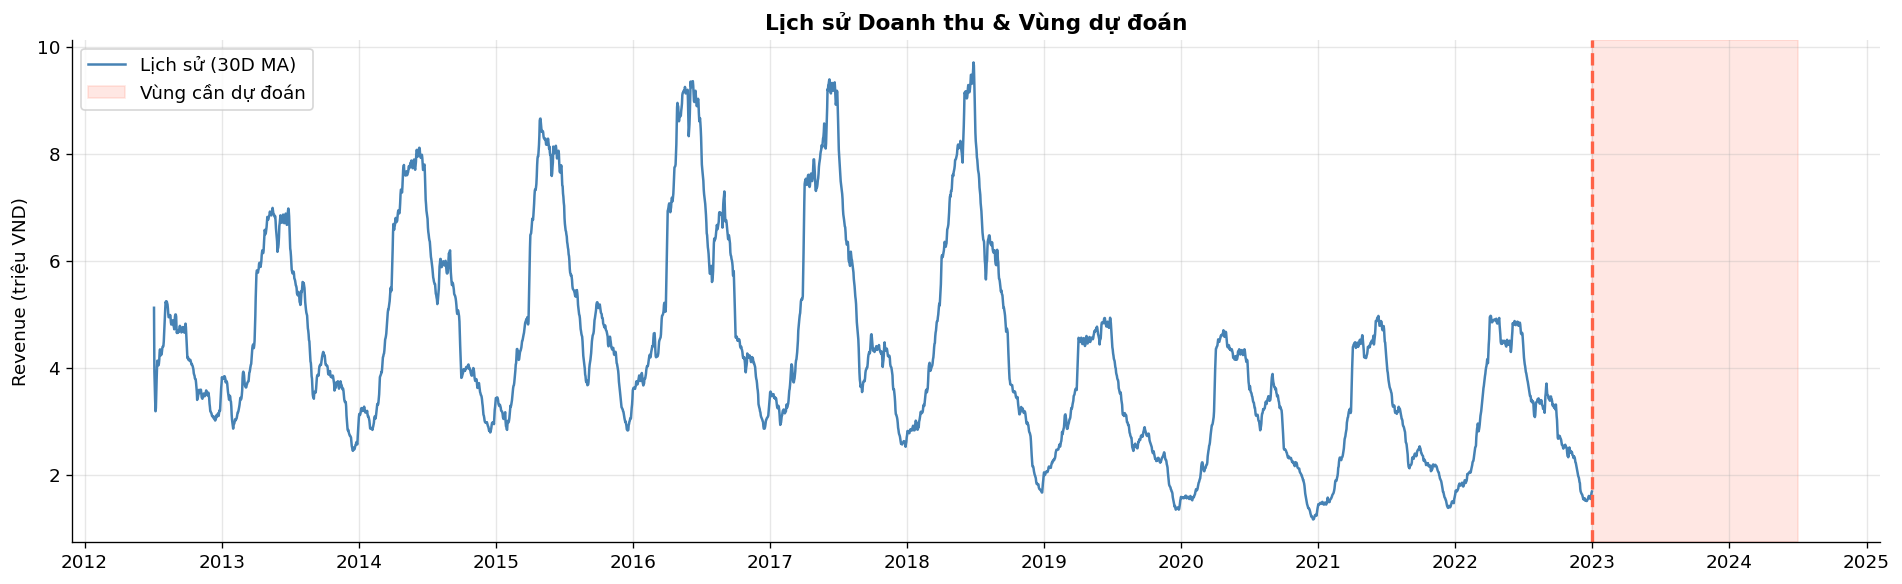

In [24]:
# Final visualization: forecast period preview
fig, ax = plt.subplots(figsize=(16, 5))

# Historical
roll_rev = sales.set_index('Date')['Revenue'].rolling('30D').mean()
ax.plot(roll_rev.index, roll_rev/1e6, lw=1.5, color='steelblue', label='Lịch sử (30D MA)')

# Forecast period span
ax.axvspan(pd.Timestamp('2023-01-01'), pd.Timestamp('2024-07-01'),
           alpha=0.15, color='tomato', label='Vùng cần dự đoán')
ax.axvline(pd.Timestamp('2023-01-01'), color='tomato', lw=2, ls='--')

ax.set_ylabel('Revenue (triệu VND)')
ax.set_title('Lịch sử Doanh thu & Vùng dự đoán', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('eda_12_forecast_zone.png', bbox_inches='tight')
plt.show()